# Autocorrelación

La autocorrelación es una herramienta estadística y de procesamiento de señales que mide el grado de similitud entre una señal $x(t)$ y una versión desplazada en el tiempo de sí misma, $x(t - \tau)$, en función del retardo o lag $\tau$



- $cov(x,x)=var(x)$
- $cov(c,x)=0$
- $cov(x,y)=cov(y,x)$
- $cov(ax,y)=a\quad  cov(x,y)$
- $cov(x+c,y)=cov(x,y)$

Si x,y son independientes, entonces:

$Cov(x,y)=E[XY]-E[X]E[Y]$

es espurio

In [13]:
#@title Covarianza de una constante
import numpy as np
import matplotlib.pyplot as plt
seed = np.random.seed(1956)
x = np.random.normal(0,1,10)
y= np.full_like(x,7)
print(np.var(x))
print("-------")
print(np.cov(x,y,bias=False))

0.9306950603803609
-------
[[1.03410562 0.        ]
 [0.         0.        ]]


In [11]:
#@title Indice de Variables Independientes

n=10000
x=np.random.normal(0,1,n)
y=np.random.normal(0,1,n)
print(np.var(x))
print(np.cov(x,y,bias=False))

0.9917451741893919
[[ 0.99184436 -0.01677249]
 [-0.01677249  1.01335347]]


### Coeficiente de Correlación de Pearson y Covarianza

#### 1. Definiciones Matemáticas

* **Covarianza Poblacional:**
  $$\operatorname{Cov}(X,Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])] = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]$$

* **Covarianza Muestral (Insesgada, `ddof=1`):**
  $$s_{xy} = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

* **Coeficiente de Correlación Poblacional ($\rho$):**
  $$\rho_{X,Y} = \frac{\operatorname{Cov}(X,Y)}{\sigma_X \sigma_Y} = \frac{\mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]}{\sqrt{\mathbb{E}[X^2] - (\mathbb{E}[X])^2} \sqrt{\mathbb{E}[Y^2] - (\mathbb{E}[Y])^2}}$$

* **Coeficiente de Correlación Muestral ($r_{xy}$):**
  $$r_{xy} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$$

---

#### 2. Propiedades Fundamentales

1. **Acotamiento (Desigualdad de Cauchy-Schwarz):**
   $$-1 \le r(X,Y) \le 1$$
   * $\vert{}r\vert{} = 1$: Existe una relación lineal determinista perfecta.
   * $r = 0$: Ausencia total de asociación de tipo lineal.

2. **Autocorrelación Unitaria:**
   $$r(X,X) = 1 \quad \text{si } \operatorname{Var}(X) > 0$$

3. **Simetría Conmutativa:**
   $$r(X,Y) = r(Y,X)$$

4. **Invarianza ante Transformaciones de Escala (Cambio de Unidad):**
   $$r(aX, bY) = \operatorname{signo}(a \cdot b) \cdot r(X,Y) \quad \forall a, b \neq 0$$
   * Para el caso particular $b = 1$:
   
     $$r(aX, Y) = \frac{a}{\vert{}a\vert{}} r(X,Y) = \operatorname{signo}(a) \cdot r(X,Y)$$

5. **Invarianza ante Traslaciones (Cambio de Origen):**
   $$r(X + c, Y + d) = r(X,Y) \quad \forall c, d \in \mathbb{R}$$

6. **Relación con la Independencia Estocástica:**
   $$X, Y \text{ independientes} \implies \mathbb{E}[XY] = \mathbb{E}[X]\mathbb{E}[Y] \implies \operatorname{Cov}(X,Y) = 0 \implies r(X,Y) = 0$$
   *(Nota: El recíproco no es necesariamente cierto; $r = 0$ no implica independencia si existen relaciones no lineales).*

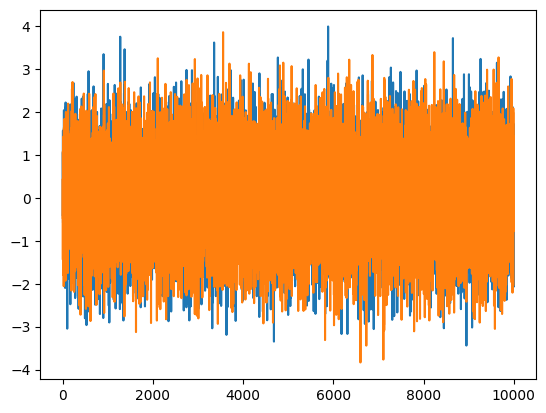

In [12]:
plt.plot(x)
plt.plot(y)

## Vector de Tiempo y Señales Sinusoidales
En la vida real no existen mediciones continuas, por eso existe la frecuencia de muestreo **(registro)**, hace la diferencia en reconstruir la señal y crear una diferente

### Señal sinusoidal
una señal sinusoidal es una señal que depende del tiempo
$$s_1(t)=Asin(t)$$

- *t* : fase
- *A* : amplitud
- *Periodo* : intervalo de tiempo en el que la señal se repite **(ciclo)** se mide sobre tiempo
- *Frecuencia* : es el inverso del periodo, cuantos ciclos hace por onstante de tiempo
- max($s_1$) = A
- min($s_1$) = -A

#### Fase
Para meter la frecuencia que yo quiero, *ejemplo* : 2
$$s_1(t)=Asin(2\pi f t+\phi_0)$$

- $\phi_0$ fase inicial

> nota: nos estamos moviendo en el tiempo


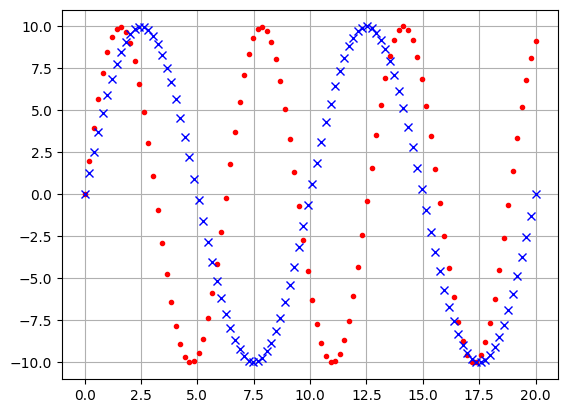

In [22]:
fr=5 #puntos que se registran en un segundo
fin=20
vTiempo=np.linspace(0,fin,fr*fin)

s_1=10*np.sin(vTiempo)
manipualte=np.pi*2 #Indispensable para manipular la frecuencia de la onda
frecuencia=1/10
s_2=10*np.sin(manipualte*frecuencia*vTiempo)
plt.plot(vTiempo,s_1,".r")
plt.plot(vTiempo,s_2,"xb")
plt.grid(True)


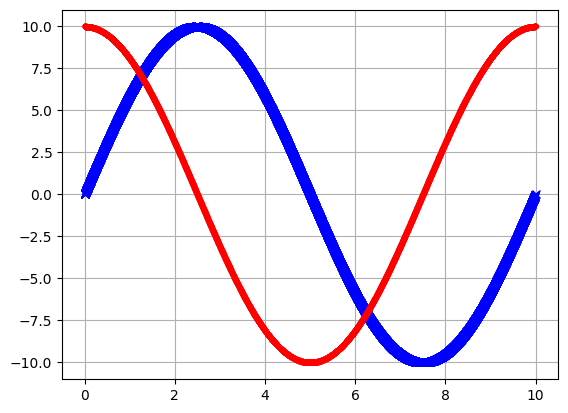

In [ ]:
s_3=10*np.sin(manipualte*frecuencia*vTiempo)
phi=np.pi/2
s_4=10*np.sin(manipualte*frecuencia*vTiempo+phi)
plt.plot(vTiempo,s_3,"xb")
plt.plot(vTiempo,s_4,".r")
plt.grid(True)
plt.show()

## Análisis Autocorrelación

funcion de autocorrelacion
$$\sum_{t=1}^{N-\tau}(x_t-\bar{x})(x_{t+\tau}-\bar{x})$$
para la señal
$$s_1(t)=Asin(2\pi (2) t+ \frac{\pi}{2})$$

$\tau=100$
$r(\tau)->x ~ N(0,1)$

#### gausiano
calcular la correlacion del ruido gausiano
#### 3
corr(sen,cos)
